Tarefas 
- entender porque o shap do tradicional gbr nao esta compativel com o artigo. sera que foi usado set de treino? 
- terminar de importar os codigos de injecao de ruidos e analises morfologicas
- Consolidar todas as "observacao" para melhor entendimento
- Em relação ao Shap values entender as diferencas nos tipos de graficos



# 0. Imports and global configuration


In [80]:
import numpy as np
import pandas as pd
import shap

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_predict,KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [81]:

RANDOM_STATE = 42
TEST_SIZE = 0.2

GBR_PARAMS = dict(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)


# 1. Data loading and description 

In [82]:
FILE_PATH = "./content/dados_jamovi.xlsx"
TARGET_COL = "Velocity (mean) [µm/s]"

data = pd.read_excel(FILE_PATH)

if TARGET_COL not in data.columns:
    raise ValueError(f"Target não encontrada: {TARGET_COL}")

numeric_data = data.select_dtypes(include=[np.number])

# 2. Declare predictors and target variable

In [83]:
X = numeric_data.drop(columns=[TARGET_COL])
y = numeric_data[TARGET_COL]


In [84]:
# Tratando nulos

# mask = X.notna().all(axis=1) & y.notna()
# X, y = X.loc[mask], y.loc[mask]

In [85]:
# Tratando nulos (old)

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
X = pd.DataFrame(X,columns=numeric_data.drop(columns=[TARGET_COL]).columns)

# 3. Split train and test set

In [ ]:
def holdout_split (X, y, TEST_SIZE, RANDOM_STATE):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    return X_train, X_test, y_train, y_test 

# 3. Modeling Experiments

## 3.1. Experiment A - Traditional Gradient Boosting Regressor (baseline)


### 3.1.1. Cross-Validation 


### 3.1.2. Holdout

### Train and predict

In [87]:
def train_gbr(X_train, y_train, X_test, params):
    model = GradientBoostingRegressor(**params)
    model.fit(X_train, y_train)
    return model.predict(X_test), model 

In [88]:
y_pred_a, trad_gbr_model = train_gbr(X_train, y_train, X_test, GBR_PARAMS)

df_eval_a = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_a,
    "residuals": y_test - y_pred_a,
    "experiment": "Traditional GBR"
})



## Experiment B - Physics-based feature engineering Gradient Boosting Regressor (PFE - GBR)


### Feature Engineering - Phisical features

In [89]:
def compute_physics_features(df, target_col):
    rho_f = 1000.0
    mu = 0.001
    g = 9.81
    rho_p = 2600.0

    A = df["Area (mean) [µm²]"] * 1e-12
    r = df["Radius (max) (mean) [µm]"] * 1e-6
    v = df[target_col] * 1e-6  # ⚠️ leakage explícito

    d = 2.0 * np.sqrt(A / np.pi)

    Re = (rho_f * v * d) / mu
    Re = Re.where(Re > 0).replace([np.inf, -np.inf], np.nan)

    Cd = 24.0 / Re
    Fd = 0.5 * rho_f * Cd * A * v**2
    r2 = r**2
    Stokes = (2 / 9) * ((rho_p - rho_f) * g * r2 / mu)

    return pd.DataFrame({
        "PFE_Re": Re,
        "PFE_Cd": Cd,
        "PFE_Fd": Fd,
        "PFE_r2": r2
    }, index=df.index)


In [90]:
def compute_physics_features_old(df, target_col):
    rho_f = 1000.0
    mu = 0.001
    g = 9.81
    rho_p = 2600.0

    A = df["Area (mean) [µm²]"] * 1e-12
    r = df["Radius (max) (mean) [µm]"] * 1e-6
    v = df[target_col] * 1e-6  # 

    # d = 2.0 * np.sqrt(A / np.pi)

    Re = (rho_f * v * r) / mu
    Re = Re.where(Re > 0).replace([np.inf, -np.inf], np.nan)

    Cd = 24.0 / Re
    Fd = 0.5 * rho_f * Cd * A * v**2
    r2 = r**2
    Stokes = (2 / 9) * ((rho_p - rho_f) * g * r2 / mu)

    return pd.DataFrame({
        "PFE_Re": Re,
        "PFE_Cd": Cd,
        "PFE_Fd": Fd,
        "PFE_r2": r2
    }, index=df.index)


In [91]:
X

,Dmax (mean) [µm],Dmed (mean) [µm],Dmin (mean) [µm],Area (mean) [µm²],Distance (sum) [µm],Rel.Time (num) [s],Area (polygon) (mean) [µm²],Area/Box (mean) [µm²],Axis (major) (mean) [µm],Axis (minor) (mean) [µm],...,Perim. (convex) (mean) [µm],Perim. (ellipse) (mean) [µm],Perim. (ratio) (mean) [µm],Perimeter2 (mean) [µm],Perimeter3 (mean) [µm],Radius (max) (mean) [µm],Radius (min) (mean) [µm],Roundness (mean),Size (length) (mean) [µm],Size (width) (mean) [µm]
0,2278.275745,1551.198298,711.606809,1.612164e+06,6438.99,47.0,1466525.53,0.46,2284.51,978.75,...,5746.35,5338.09,0.82,7615.24,7006.98,1329.19,267.71,2.67,2360.02,1219.27
1,3442.800833,2611.194583,1959.983750,5.709536e+06,5554.67,24.0,5488243.60,0.73,3343.78,2207.01,...,9110.69,8811.35,0.90,10708.58,10125.68,1770.54,859.83,1.49,3405.16,2470.43
2,2372.206296,1943.840370,1434.028889,3.149271e+06,5889.41,27.0,2978574.57,0.61,2279.25,1842.56,...,7027.62,6492.88,0.81,9172.29,8647.90,1434.45,511.19,2.01,2495.45,2040.84
3,1921.425405,1496.906486,1080.961892,1.835665e+06,6495.60,37.0,1711958.32,0.63,1838.61,1294.87,...,5162.67,4959.59,0.84,6476.37,6131.23,1031.68,466.54,1.75,1889.67,1450.77
4,1987.391429,1533.741429,934.360000,1.807783e+06,1116.64,7.0,1682195.05,0.59,2114.39,1112.67,...,5396.27,5191.92,0.90,6369.07,5980.95,1079.78,418.74,1.69,2009.11,1196.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
911,3136.153200,2408.649600,1890.947000,4.812445e+06,14073.32,50.0,4617799.53,0.63,2953.81,2111.67,...,8412.13,8012.02,0.95,9366.66,8880.15,1652.12,837.00,1.36,2990.50,2219.97
912,2812.451333,2076.334800,1401.347973,3.474430e+06,12550.62,75.0,3275391.71,0.54,2682.56,1796.98,...,7902.23,7138.59,0.81,10699.62,9812.46,1508.24,604.67,2.37,2809.86,2132.47
913,2799.677391,1894.347536,813.373529,2.391134e+06,11730.02,69.0,2226172.89,0.46,2987.35,1128.51,...,6990.49,6801.41,0.92,8057.59,7628.13,1618.95,180.22,2.12,2959.49,1275.28
914,2312.610000,1682.490200,794.600408,2.213474e+06,8343.88,50.0,2042021.79,0.60,2319.41,1303.58,...,6160.02,5803.88,0.77,8521.31,8015.60,1237.14,213.92,2.52,2295.89,1519.96


In [92]:
physics_features = compute_physics_features(data.loc[X.index], TARGET_COL)
# physics_features = compute_physics_features_old(data.loc[X.index], TARGET_COL)


X_train_pfe = pd.concat(
    [X_train, physics_features.loc[X_train.index]], axis=1
)
X_test_pfe = pd.concat(
    [X_test, physics_features.loc[X_test.index]], axis=1
)



### Training model

In [93]:
y_pred_b, pfe_gbr_model = train_gbr(
    X_train_pfe, 
    y_train,
    X_test_pfe,
    GBR_PARAMS
)

df_eval_b = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_b,
    "residuals": y_test - y_pred_b,
    "experiment": "PFE-GBR"
    })


In [94]:
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


In [95]:

results = pd.DataFrame.from_dict({
    "Traditional GBR": evaluate(y_test, y_pred_a),
    "PFE-GBR": evaluate(y_test, y_pred_b)
}, orient="index")

results

,MAE,RMSE,R2
Traditional GBR,232.035470,371.830841,0.916006
PFE-GBR,133.302215,282.198174,0.951620


# 4. Holdout Evaluation and Error Interpretation

In [96]:
df_eval = pd.concat([df_eval_a, df_eval_b], axis=0).copy()

df_eval_trad = df_eval[df_eval["experiment"] == "Traditional GBR"]
df_eval_pfe  = df_eval[df_eval["experiment"] == "PFE-GBR"]

## Real vs Predicted Velocity


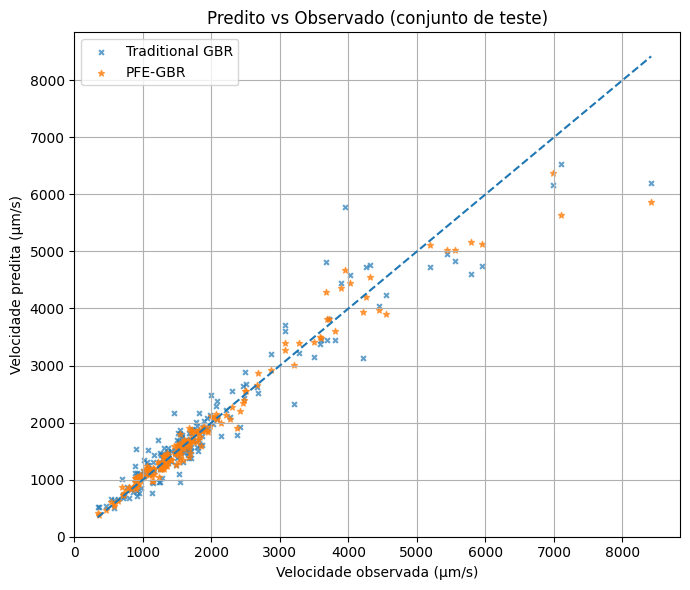

In [97]:
plt.figure(figsize=(7, 6))

for df_, label, marker, size in [
    (df_eval_trad, "Traditional GBR", "x", 12),
    (df_eval_pfe,  "PFE-GBR", "*", 20),
]:
    plt.scatter(
        df_["y_true"],
        df_["y_pred"],
        marker=marker,
        s=size,
        alpha=0.7,
        label=label
    )

lims = [
    min(df_eval["y_true"].min(), df_eval["y_pred"].min()),
    max(df_eval["y_true"].max(), df_eval["y_pred"].max())
]

plt.plot(lims, lims, linestyle="--")
plt.xlim([lims[0]-1*lims[0],lims[1]+0.05*lims[1]])
plt.ylim([lims[0]-1*lims[0],lims[1]+0.05*lims[1]])

plt.xlabel("Velocidade observada (µm/s)")
plt.ylabel("Velocidade predita (µm/s)")
plt.title("Predito vs Observado (conjunto de teste)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


--------------------------
**Tentando chegar nos resultados do artigo**

- Cheguei igual ao artigo! Configurações:
    - imputa media em vez de descartar os nulos
    - faz a feature engineering antiga
    - as predições são os resultados da cross validation 

In [98]:
# a funcao train_gbr na verdade ja faz as inferencias. encontrar um outro nome
y_pred_b_debug, pfe_gbr_model_debug = train_gbr(
    X_train_pfe, 
    y_train,
    X_train_pfe,
    GBR_PARAMS
)

y_pred_a_debug, trad_gbr_model_debug = train_gbr(X_train, y_train, X_train, GBR_PARAMS)

In [99]:
model = GradientBoostingRegressor(**GBR_PARAMS)

In [100]:
physics_features_debug = compute_physics_features_old(data.loc[X.index], TARGET_COL)


X_pfe = pd.concat(
    [X, physics_features_debug], axis=1
)




In [101]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_pred_a = cross_val_predict(model, X, y, cv=kfold)
cv_pred_b = cross_val_predict(model, X_pfe, y, cv=kfold)

In [102]:
dict_a_debug = {
    "y_pred": pd.Series(cv_pred_a), 
    "y_true": y.reset_index(drop=True), 
    "model": "Trad"}

df_a_debug = pd.DataFrame(dict_a_debug)

dict_b_debug = {
    "y_pred": pd.Series(cv_pred_b), 
    "y_true": y.reset_index(drop=True), 
    "model": "PFE"}

df_b_debug = pd.DataFrame(dict_b_debug)

df_debug = pd.concat([df_a_debug, df_b_debug])
df_debug = df_debug.reset_index(drop=True)


In [103]:

df_eval_trad_debug = df_debug.loc[df_debug["model"] == "Trad", :]
df_eval_pfe_debug = df_debug.loc[df_debug["model"] == "PFE", :]

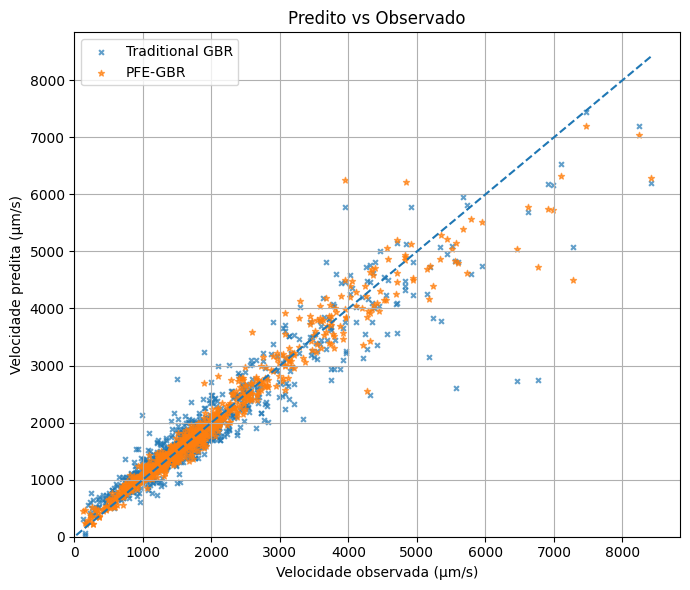

In [104]:
plt.figure(figsize=(7, 6))

for df_, label, marker, size in [
    (df_eval_trad_debug, "Traditional GBR", "x", 12),
    (df_eval_pfe_debug,  "PFE-GBR", "*", 20),
]:
    plt.scatter(
        df_["y_true"],
        df_["y_pred"],
        marker=marker,
        s=size,
        alpha=0.7,
        label=label
    )

lims = [
    min(df_debug["y_true"].min(), df_debug["y_pred"].min()),
    max(df_debug["y_true"].max(), df_debug["y_pred"].max())
]

plt.plot(lims, lims, linestyle="--")
plt.xlim([lims[0]-1*lims[0],lims[1]+0.05*lims[1]])
plt.ylim([lims[0]-1*lims[0],lims[1]+0.05*lims[1]])

plt.xlabel("Velocidade observada (µm/s)")
plt.ylabel("Velocidade predita (µm/s)")
plt.title("Predito vs Observado")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [105]:
df_b_debug.head()

,y_pred,y_true,model
0,1488.656789,1399.779783,PFE
1,2273.504971,2415.071739,PFE
2,2344.774550,2265.156923,PFE
3,1690.001367,1804.333056,PFE
4,1636.239657,1861.068333,PFE


In [106]:
# 8) Métricas (apenas conferência)
mae = mean_absolute_error(df_b_debug['y_true'], df_b_debug['y_pred'])
rmse = np.sqrt(mean_squared_error(df_b_debug['y_true'], df_b_debug['y_pred']))
r2_sc = r2_score(df_b_debug['y_true'], df_b_debug['y_pred'])


In [107]:
model.fit(X_pfe,y)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [108]:

print(f"MAE:  {mae:.2f} µm/s")
print(f"RMSE: {rmse:.2f} µm/s")
print(f"R²:   {r2_sc:.3f}")

# 9) SHAP (TreeExplainer)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_pfe)


MAE:  135.69 µm/s
RMSE: 262.88 µm/s
R²:   0.951


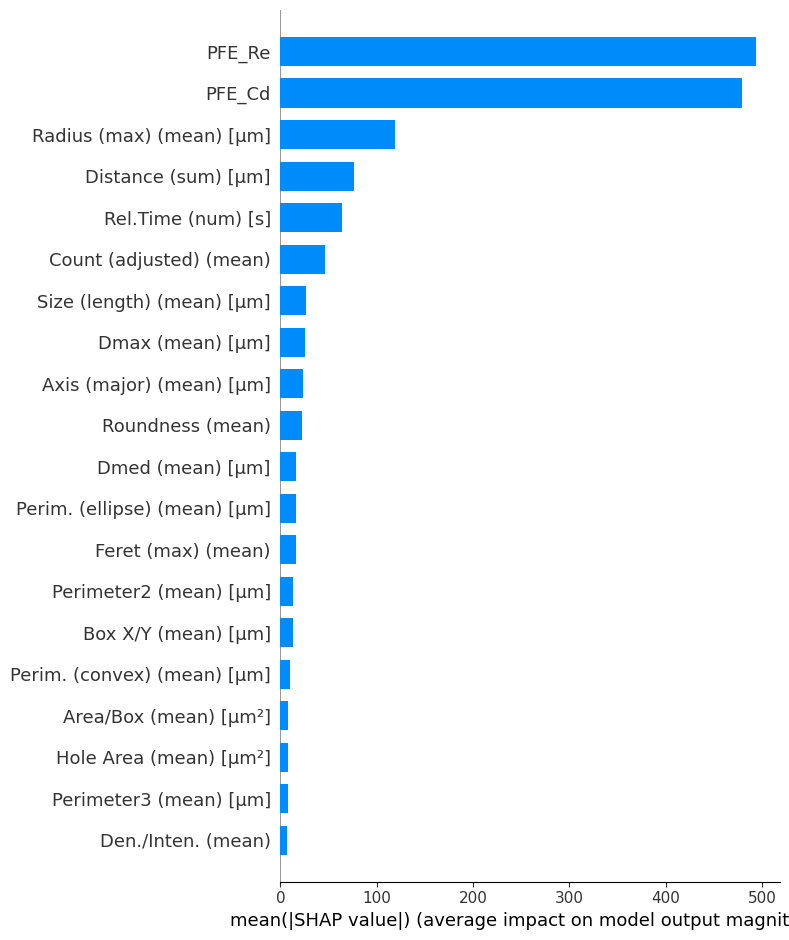

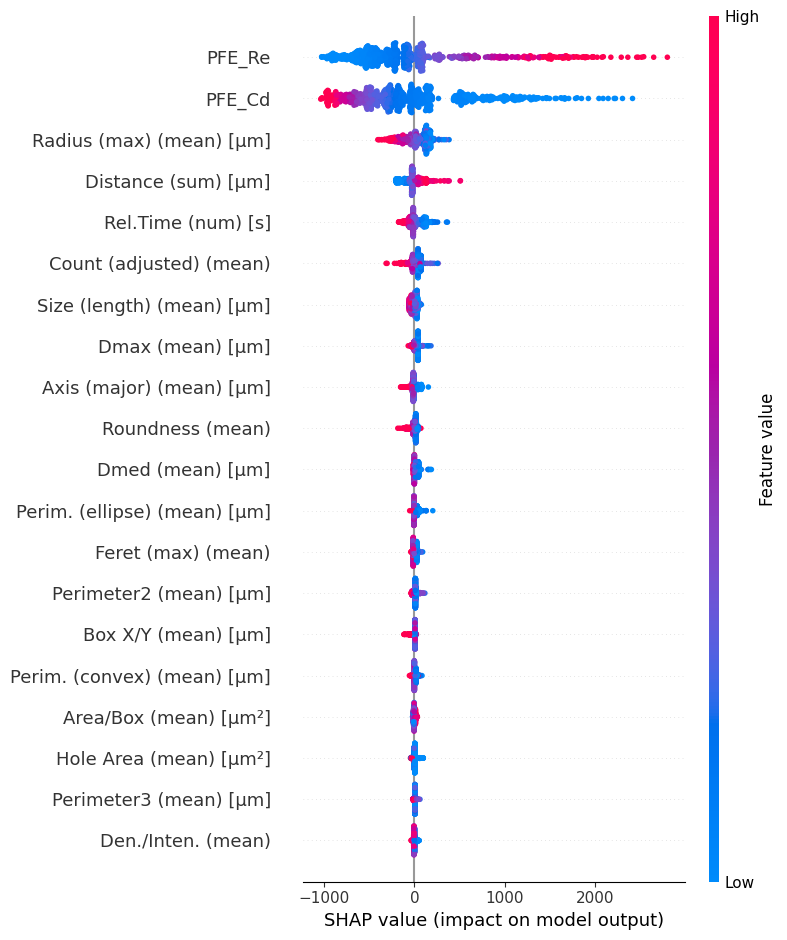

In [109]:

# 10) Gráfico de importância (bar) e summary (beeswarm)
shap.summary_plot(shap_values, X_pfe, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_pfe, show=False)
plt.tight_layout()
plt.show()

## Error Analysis

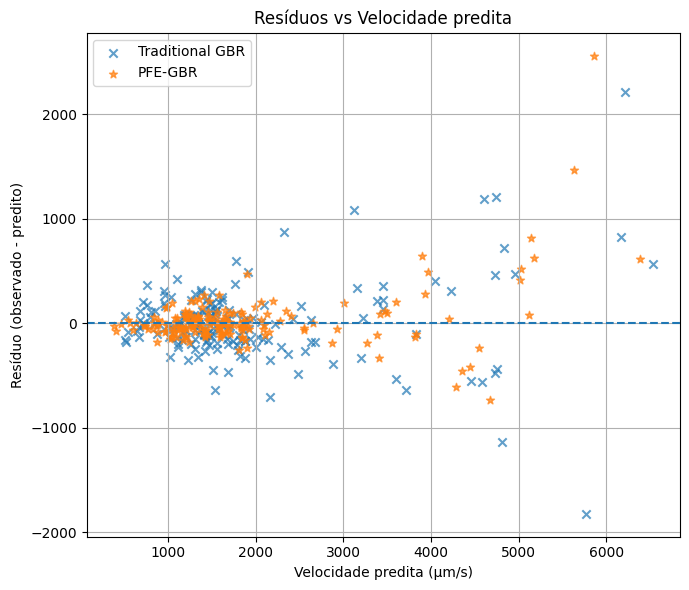

In [110]:
plt.figure(figsize=(7, 6))

plt.scatter(
    df_eval_trad["y_pred"],
    df_eval_trad["residuals"],
    marker="x",
    alpha=0.7,
    label="Traditional GBR"
)

plt.scatter(
    df_eval_pfe["y_pred"],
    df_eval_pfe["residuals"],
    marker="*",
    alpha=0.7,
    label="PFE-GBR"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Velocidade predita (µm/s)")
plt.ylabel("Resíduo (observado - predito)")
plt.title("Resíduos vs Velocidade predita")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Model Interpretability - SHAP Values

##### Observacao 

Mesmo o codigo do professor apresenta resultados de shap diferentes do artigo. as tendencias sao similares, mas nao da pra falar que sao a mesma coisa

## shap.TreeExplainer

### Tradicional GBR

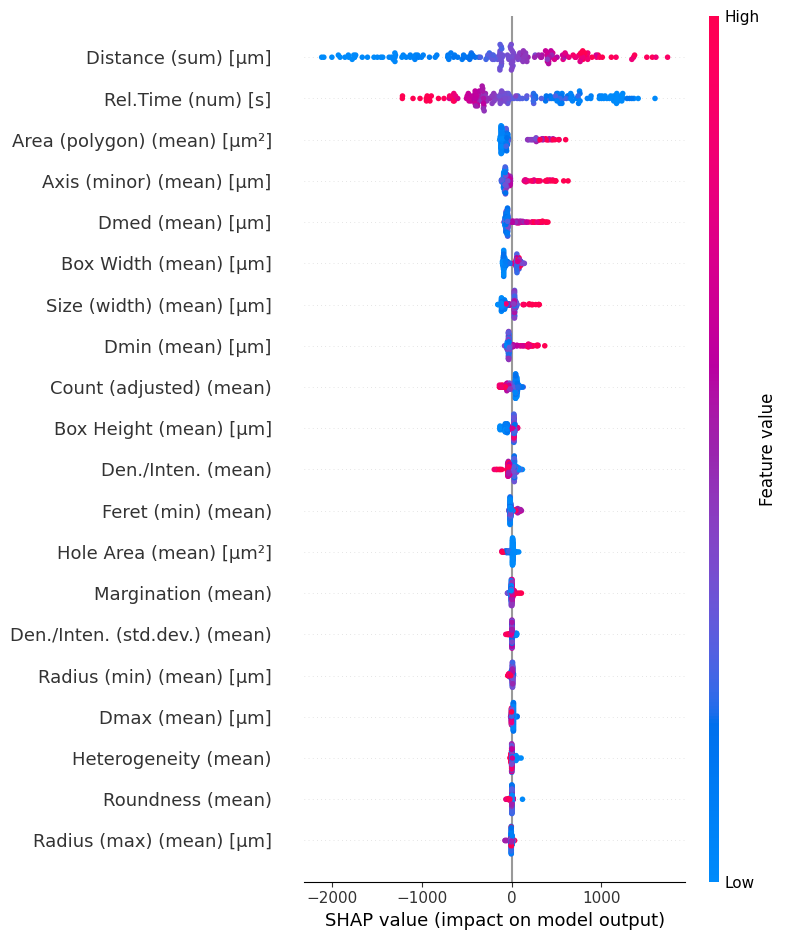

In [111]:
# Essa implementacao nao esta de acordo com o codigo. Mas é curioso entender o porque os valores se distanciaram tanto do apresentado no artigo com TreeExplainer
explainer = shap.TreeExplainer(trad_gbr_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)


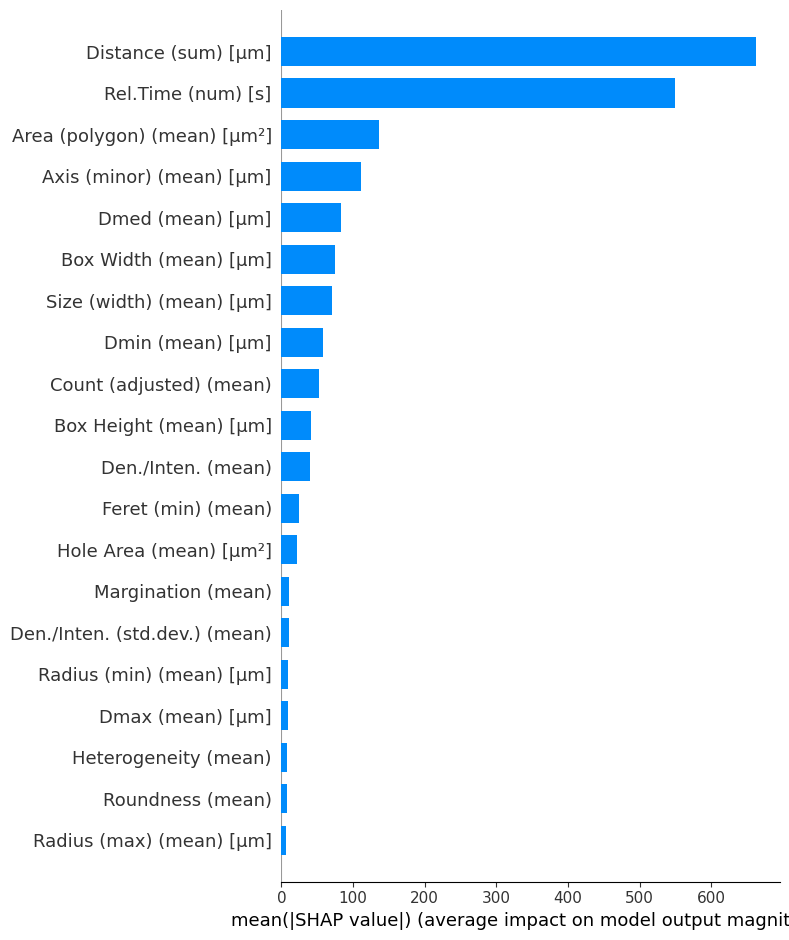

In [112]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()

### PFE - GBR

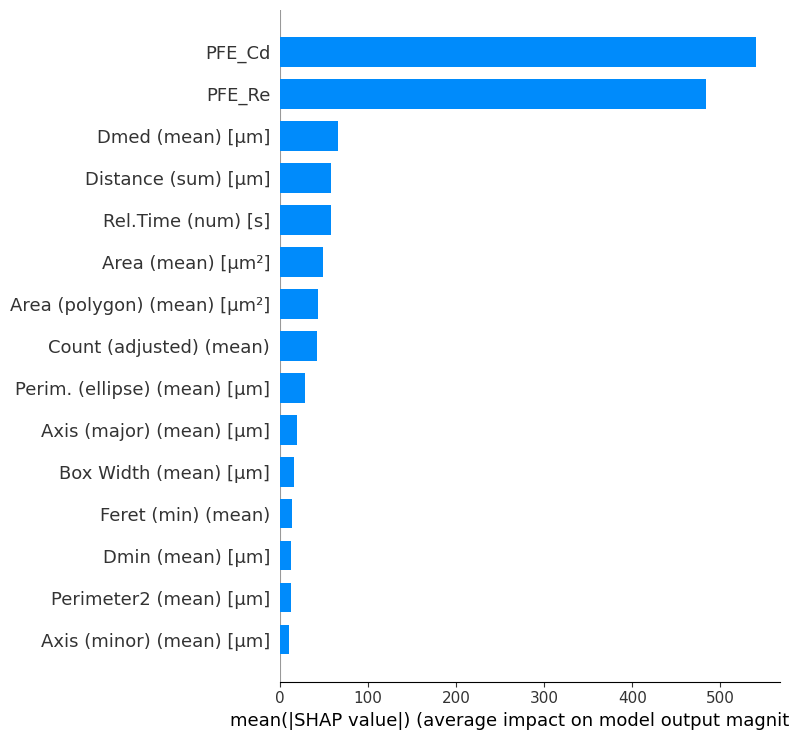

In [113]:
explainer = shap.TreeExplainer(
    pfe_gbr_model
)

shap_values = explainer.shap_values(X_test_pfe)

shap.summary_plot(
    shap_values,
    X_test_pfe,
    plot_type="bar",
    max_display=15
)

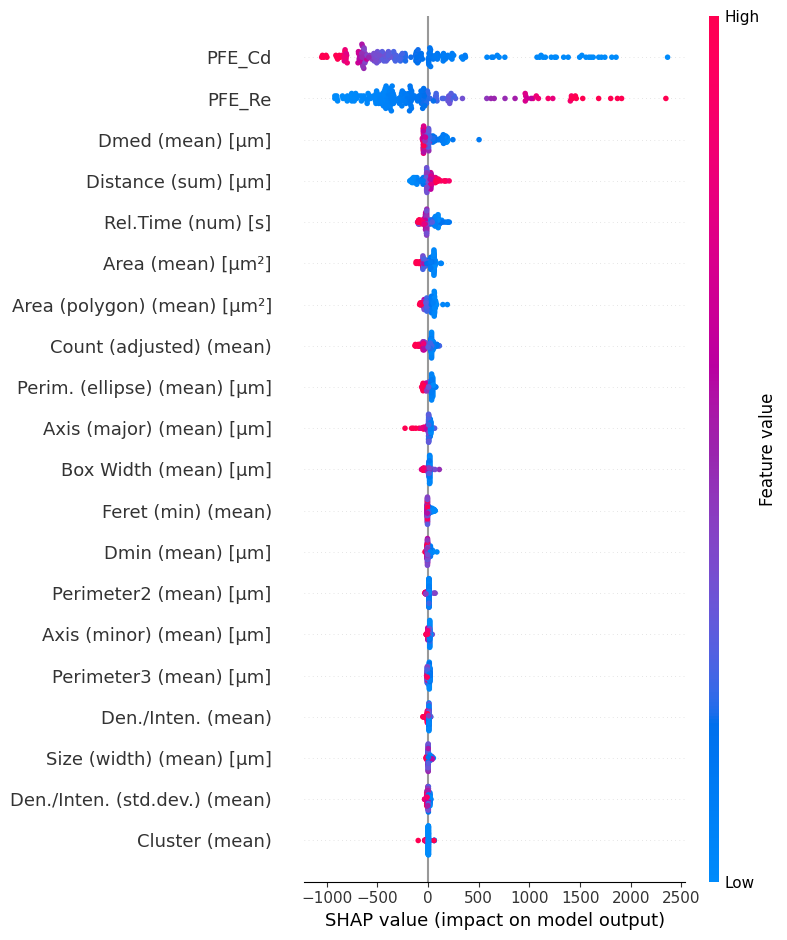

In [114]:
# PFE - GBR
explainer = shap.TreeExplainer(pfe_gbr_model)
shap_values_pfe = explainer.shap_values(X_test_pfe)

shap.summary_plot(shap_values_pfe, X_test_pfe, show=False)


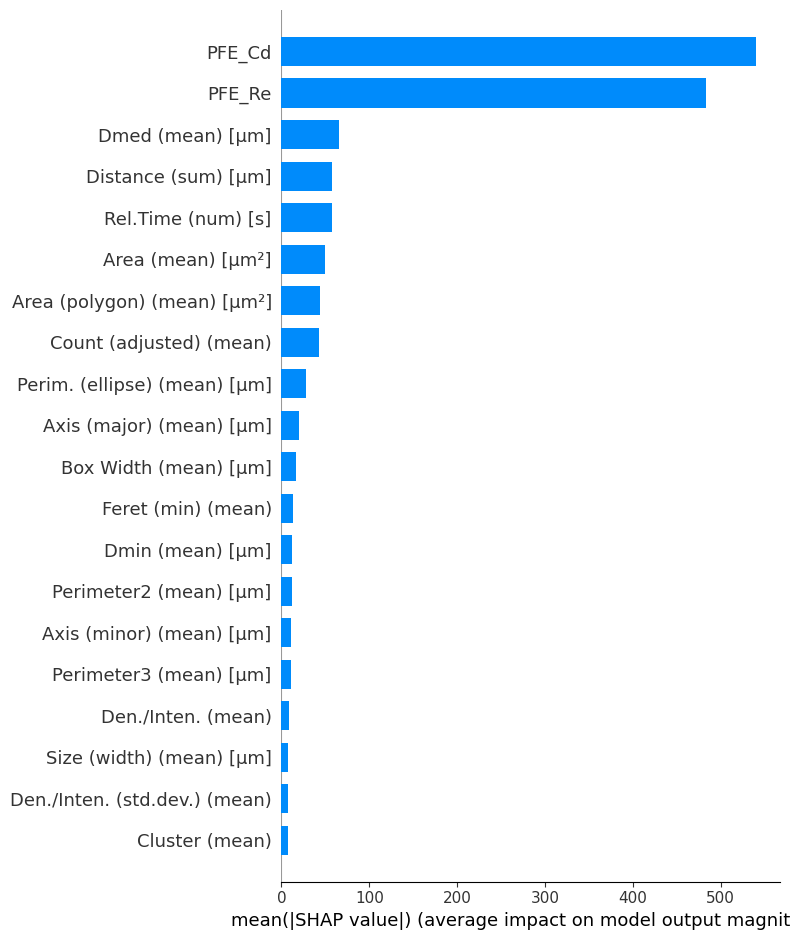

In [115]:
shap.summary_plot(shap_values_pfe, X_test_pfe, plot_type="bar", show=False)
plt.tight_layout()

# 6. Bootstrap analysis


In [116]:
def bootstrap_mae(
    y_true,
    y_pred,
    n_boot=100,
    random_state=42
):
    """
    Bootstrap do MAE a partir de pares (y_true, y_pred).

    Parâmetros
    ----------
    y_true : array-like
        Valores observados.
    y_pred : array-like
        Valores preditos pelo modelo (fixos).
    n_boot : int
        Número de reamostragens bootstrap.
    random_state : int
        Seed para reprodutibilidade.

    Retorna
    -------
    dict com:
        mae_boot : np.ndarray
        mean_mae : float
        std_mae  : float
        ci_low   : float (IC 2.5%)
        ci_high  : float (IC 97.5%)
    """
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if len(y_true) != len(y_pred):
        raise ValueError("y_true e y_pred devem ter o mesmo tamanho")

    n = len(y_true)
    mae_boot = np.empty(n_boot)

    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)  # amostragem com reposição
        mae_boot[i] = mean_absolute_error(
            y_true[idx],
            y_pred[idx]
        )

    mean_mae = mae_boot.mean()
    std_mae  = mae_boot.std(ddof=1)
    ci_low, ci_high = np.percentile(mae_boot, [2.5, 97.5])

    return {
        "mae_boot": mae_boot,
        "mean_mae": mean_mae,
        "std_mae": std_mae,
        "ci_low": ci_low,
        "ci_high": ci_high
    }


In [117]:
bootstrap_results = bootstrap_mae(
    y_true=y_test,
    y_pred=y_pred_b,
    n_boot=100,
    random_state=42
)

print("Bootstrap MAE (PFE-GBR)")
print(f"Média: {bootstrap_results['mean_mae']:.2f} µm/s")
print(f"DP:    {bootstrap_results['std_mae']:.2f} µm/s")
print(
    f"IC 95%: "
    f"[{bootstrap_results['ci_low']:.2f}, "
    f"{bootstrap_results['ci_high']:.2f}] µm/s"
)

Bootstrap MAE (PFE-GBR)
Média: 132.66 µm/s
DP:    19.58 µm/s
IC 95%: [100.19, 170.89] µm/s


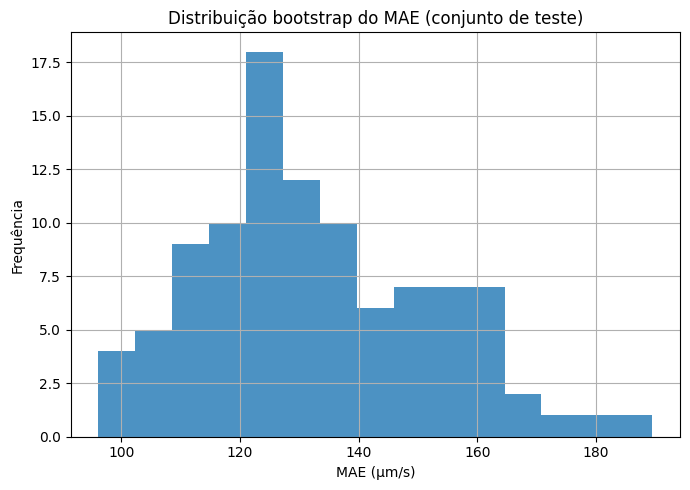

In [118]:
plt.figure(figsize=(7, 5))

plt.hist(
    bootstrap_results["mae_boot"],
    bins=15,
    alpha=0.8
)

plt.xlabel("MAE (µm/s)")
plt.ylabel("Frequência")
plt.title("Distribuição bootstrap do MAE (conjunto de teste)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 7. Robustness Analysis - Noise Injection

## 7.1. Performance Degradation Under Noise

# 8. Error Analysis by Morphological Class